## Tensorflow and Keras

[**TensorFlow**](https://www.tensorflow.org/) is an open-source end-to-end platform developed by Google for machine learning and deep learning tasks. It provides a comprehensive ecosystem of tools, libraries, and community resources that lets researchers and developers build and deploy ML-powered applications.

<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2015/Session%2015_4%20-%20Real%20Data%20Analysis.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2015/Session%2015_4%20-%20Real%20Data%20Analysis.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

### 🔧 What is Keras?

[**Keras**](https://keras.io/) is a high-level API built on top of TensorFlow that simplifies the process of building and training neural networks. It offers a user-friendly and modular approach to model development, making it easier for beginners and experts alike.

---


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('fake_reg.csv')
df.head()

,price,feature1,feature2
0,461.527929,999.787558,999.766096
1,548.130011,998.861615,1001.042403
2,410.297162,1000.070267,998.844015
3,540.382220,999.952251,1000.440940
4,546.024553,1000.446011,1000.338531


### Explore the data


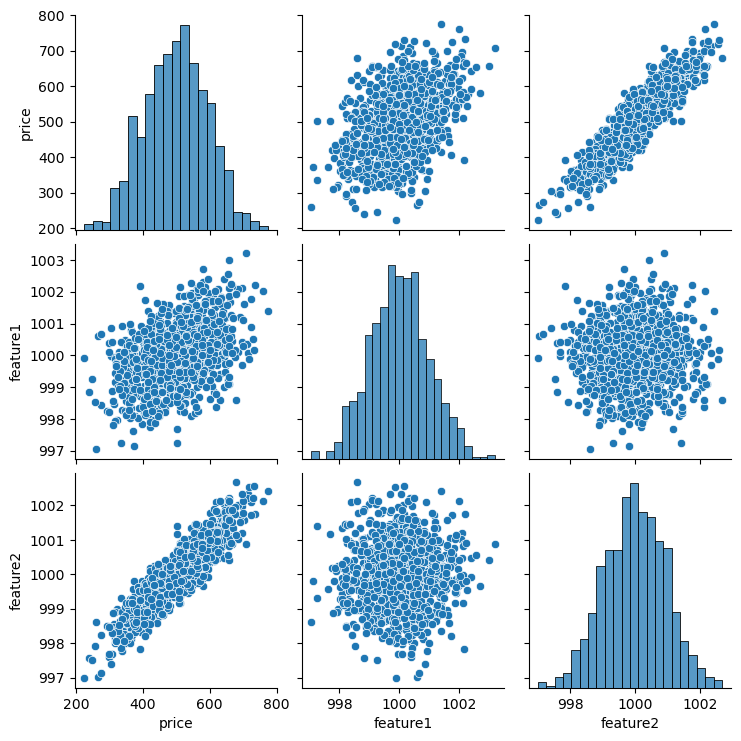

In [2]:
sns.pairplot(df)

### Test/Train Split

In [2]:
from sklearn.model_selection import train_test_split

X = df[['feature1','feature2']].values
y = df['price'].values
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [4]:
X_train.shape

(700, 2)

In [5]:
X_test.shape

(300, 2)

In [6]:
y_train.shape

(700,)

In [7]:
y_test.shape

(300,)

## Feature scaling with MinMaxScaler  


Neural networks perform better when input features are on a similar scale. Raw data may have different ranges (e.g., one feature in hundreds, another in decimals), which can make training unstable.  

To address this, we use **`MinMaxScaler`** from `sklearn.preprocessing`, which rescales each feature to a fixed range `[0, 1]`.  

The transformation is defined as:  

$$
X' = \frac{X - X_{min}}{X_{max} - X_{min}}
$$

Where:  
- $X$ = original feature value  
- $X_{min}$ = minimum value of the feature (in the training set)  
- $X_{max} $ = maximum value of the feature (in the training set)  
- $X'$ = scaled feature value (between 0 and 1)  

👉 The scaler is **fit only on the training data** and then applied to both training and test sets. This prevents **data leakage**, meaning information from the test set doesn’t influence model training.  

In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [4]:
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## 🔹 Dense Layer

* A **fully connected (FC) layer**, also known as a dense layer, connects every neuron in the previous layer to every neuron in the current layer.
* The mathematical operation for a dense layer is:

$$
y = f(Wx + b)
$$

Where:

* $W$ = weight matrix

* $b$ = bias vector

* $f$ = activation function

* $x$ = input vector

* Number of parameters in a Dense layer:

$$
\text{params} = ( \text{input\_features} \times \text{units} ) + \text{units}
$$

Example: A Dense layer with 32 units and an input of size 10 →

$$
(10 \times 32) + 32 = 352 \text{ parameters}
$$

---

#### 🔹 Activation Layer

* The **Activation** layer applies a non-linear transformation element-wise to the inputs.
* While you can define the activation function directly in a Dense layer (`Dense(64, activation='relu')`), using a separate `Activation` layer allows more flexibility.

Common activation functions:

* **ReLU (`relu`)**: Rectified Linear Unit, widely used in hidden layers.
* **Sigmoid (`sigmoid`)**: Squashes values into \[0, 1], useful for binary classification.
* **Softmax (`softmax`)**: Produces a probability distribution, used in multi-class classification.
* **Linear (`linear`)**: No transformation, typically for regression outputs.
* **Tanh (`tanh`)**: Maps input values to \[-1, 1].



In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation

### ❓ How to Choose:

| Component                | Guidelines                                                                       |
| ------------------------ | -------------------------------------------------------------------------------- |
| **Number of Layers**     | Start with 1–2 hidden layers. Add more only if necessary.                        |
| **Units per Layer**      | Try values like 8, 16, 32. Use more if data is complex.                          |
| **Activation Functions** | ReLU for hidden layers (good for non-linearity), Linear for output (regression). |
| **Output Units**         | For regression: `1` (predicting a continuous value).                             |

> **Note:** More layers/units can increase model power, but also risk overfitting. Use validation and experimentation to tune.


### Model - as a list of layers

In [11]:
model = Sequential([
    Dense(units=2),
    Dense(units=2),
    Dense(units=2)
])

### Dense Layer Parameters

The `Dense` layer in Keras is a fully connected layer. Below is a summary of its most commonly used parameters:

| Parameter            | Type / Options                               | Description                                                                                     |
|-----------------------|-----------------------------------------------|-------------------------------------------------------------------------------------------------|
| **units**            | `int`                                        | Number of neurons (output dimensions) in the layer.                                             |
| **activation**       | `str` / `callable`                           | Activation function to apply (e.g., `'relu'`, `'sigmoid'`, `'tanh'`, `'softmax'`, `'linear'`).  |
| **use_bias**         | `bool` (default=`True`)                      | Whether to include a bias term for each neuron.                                                 |
| **kernel_initializer** | `str` / initializer object (default=`glorot_uniform`) | Method for initializing the weight matrix.                                                      |
| **bias_initializer** | `str` / initializer object (default=`zeros`) | Method for initializing the bias vector.                                                       |
| **kernel_regularizer** | Regularizer object or `None`                | Adds penalty (L1/L2) on the weights to reduce overfitting.                                      |
| **bias_regularizer** | Regularizer object or `None`                  | Adds penalty on the bias.                                                                       |
| **activity_regularizer** | Regularizer object or `None`              | Adds penalty on the layer’s output (e.g., L1/L2).                                               |
| **kernel_constraint** | Constraint object or `None`                  | Constraint applied to the weight matrix (e.g., `max_norm`).                                     |
| **bias_constraint**   | Constraint object or `None`                  | Constraint applied to the bias vector.                                                          |
| **input_shape**      | `tuple of int` (only in first layer)          | Shape of the input data (excluding batch size). Example: `(2,)` for two input features.          |


### `model.fit()` Parameters

The `fit()` method trains a Keras model for a fixed number of epochs on a dataset. Below is a table summarizing the most commonly used parameters:

| Parameter         | Type / Options                            | Description                                                                                   |
|------------------|-------------------------------------------|-----------------------------------------------------------------------------------------------|
| **x**            | `array`, `tensor`, or `Dataset`           | Input data (features).                                                                        |
| **y**            | `array`, `tensor`, or `Dataset`           | Target data (labels).                                                                         |
| **batch_size**    | `int` (default=`32`)                      | Number of samples per gradient update. Smaller batches can improve convergence but slower.   |
| **epochs**        | `int`                                     | Number of complete passes through the training dataset.                                       |
| **verbose**       | `0`, `1`, or `2`                          | Verbosity mode: `0`=silent, `1`=progress bar, `2`=one line per epoch.                        |
| **validation_split** | `float` (0.0–1.0)                       | Fraction of training data to use for validation.                                             |
| **validation_data** | Tuple `(x_val, y_val)`                   | Data on which to evaluate the loss and metrics at the end of each epoch. Overrides `validation_split`. |
| **shuffle**       | `bool` (default=`True`)                   | Whether to shuffle the training data before each epoch.                                       |
| **callbacks**     | List of `Callback` objects                 | Functions applied at specific stages during training (e.g., early stopping, learning rate scheduler). |
| **class_weight**  | Dict `{class_index: weight}`               | Weights for different classes, useful for imbalanced datasets.                                |
| **sample_weight** | Array of weights per sample                | Allows weighting individual samples during training.                                         |
| **initial_epoch** | `int`                                     | Epoch at which to start training (useful for resuming training).                              |
| **steps_per_epoch** | `int`                                   | Number of batches per epoch (useful for generators or `Dataset`).                             |
| **validation_steps** | `int`                                  | Number of validation batches to use (for generators).                                         |


In [12]:
model = Sequential()

model.add(Dense(units=32, activation='relu', input_shape=(2,)))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='linear'))
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=100, verbose=1)

Epoch 1/100


C:\Users\PC-GAM\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16081.0967   
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8866.3535 
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8842.9277 
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8831.7188 
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8841.5615 
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8768.3447  
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8858.6211 
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8795.7090 
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8798.7061  
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8955.8896  
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9045.5439 
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8855.7334 
Epoch 13/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8996.1777  
Epoch 14/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8991.1631 
Epoch 15/100
32/32 ━

### Loss Function and Optimizer in Neural Networks

When compiling a Keras model, two critical components must be defined:  
- **Loss function** → How well the model is performing.  
- **Optimizer** → How the model learns and updates its weights.  

---

#### 🔹 1. Loss Function
The **loss function** measures the difference between the model’s predictions and the actual target values. During training, the optimizer tries to minimize this value.  

In regression tasks (like predicting `price`), a common choice is **Mean Squared Error (MSE):**

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Where:  
- $y_i$ = true value  
- $\hat{y}_i$ = predicted value  
- $n$ = number of samples  

- **Properties of MSE:**  
  - Penalizes larger errors more strongly (squared term).  
  - Smooth and differentiable, making it suitable for gradient-based optimization.  
  - Works best when output values are continuous.  

Other examples of loss functions:  
- **MAE (Mean Absolute Error):** less sensitive to outliers.  
- **Binary Crossentropy:** used for binary classification.  
- **Categorical Crossentropy:** used for multi-class classification.  

---

#### 🔹 2. Optimizer
The **optimizer** updates the model’s weights during training to minimize the loss function. It controls *how fast* and *in what direction* the network learns.  

In this example, we use **Adam (Adaptive Moment Estimation):**  

- Combines advantages of **Momentum** and **RMSProp**.  
- Adapts the learning rate for each parameter individually.  
- Generally works well for most problems, making it a popular default choice.  

Update rule for parameter $\theta$:  

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t
$$
$$
v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2
$$
$$
\theta_t = \theta_{t-1} - \alpha \cdot \frac{m_t}{\sqrt{v_t} + \epsilon}
$$

Where:  
- $g_t$ = gradient at time step \(t\)  
- $m_t$ = exponentially decaying average of past gradients (momentum)  
- $v_t$ = exponentially decaying average of squared gradients  
- $\alpha$ = learning rate  
- $\beta_1, \beta_2$ = decay rates for moment estimates  
- $\epsilon$ = small constant to prevent division by zero  

---
Keep in mind what kind of problem you are trying to solve:

    # For a multi-class classification problem
    model.compile(optimizer='rmsprop',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # For a mean squared error regression problem
    model.compile(optimizer='rmsprop',
                  loss='mse')

In [6]:
model = Sequential()

model.add(Dense(4,activation='relu'))
model.add(Dense(4,activation='relu'))
model.add(Dense(4,activation='relu'))

model.add(Dense(1))

model.compile(optimizer='rmsprop',loss='mse')
model.fit(X_train,y_train,epochs=250)

Epoch 1/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 256707.4531   
Epoch 2/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256659.4688 
Epoch 3/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256610.3281 
Epoch 4/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256552.8438 
Epoch 5/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256485.5781 
Epoch 6/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256407.6406 
Epoch 7/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256318.5625 
Epoch 8/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 256217.0312 
Epoch 9/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 256102.0781 
Epoch 10/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255970.7812 
Epoch 11/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255823.4062 
Epoch 12/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255658.4219 
Epoch 13/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 255473.1875 
Epoch 14/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss

## Evaluation


In [7]:
model.history.history

{'loss': [256707.453125,
  256659.46875,
  256610.328125,
  256552.84375,
  256485.578125,
  256407.640625,
  256318.5625,
  256217.03125,
  256102.078125,
  255970.78125,
  255823.40625,
  255658.421875,
  255473.1875,
  255265.484375,
  255034.625,
  254778.125,
  254492.890625,
  254182.125,
  253837.59375,
  253459.296875,
  253046.609375,
  252595.6875,
  252104.921875,
  251568.6875,
  250989.0,
  250366.078125,
  249694.75,
  248966.625,
  248184.796875,
  247345.375,
  246450.921875,
  245492.546875,
  244469.296875,
  243374.359375,
  242211.21875,
  240975.640625,
  239671.203125,
  238278.609375,
  236819.34375,
  235271.0,
  233635.0,
  231903.40625,
  230091.90625,
  228184.953125,
  226179.125,
  224075.65625,
  221876.4375,
  219581.09375,
  217160.484375,
  214653.828125,
  212037.71875,
  209299.5625,
  206467.609375,
  203513.6875,
  200436.390625,
  197259.46875,
  193970.671875,
  190557.828125,
  187026.328125,
  183379.125,
  179633.21875,
  175760.8125,
  171808.

In [8]:
loss = model.history.history['loss']

Text(0.5, 1.0, 'Training Loss per Epoch')

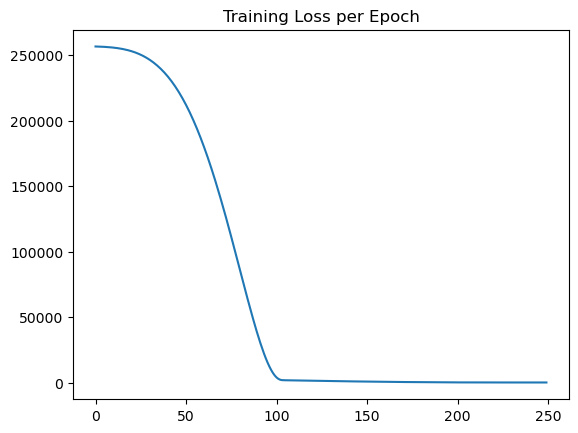

In [9]:
sns.lineplot(x=range(len(loss)),y=loss)
plt.title("Training Loss per Epoch")

Text(0.5, 1.0, 'Training Loss per Epoch')

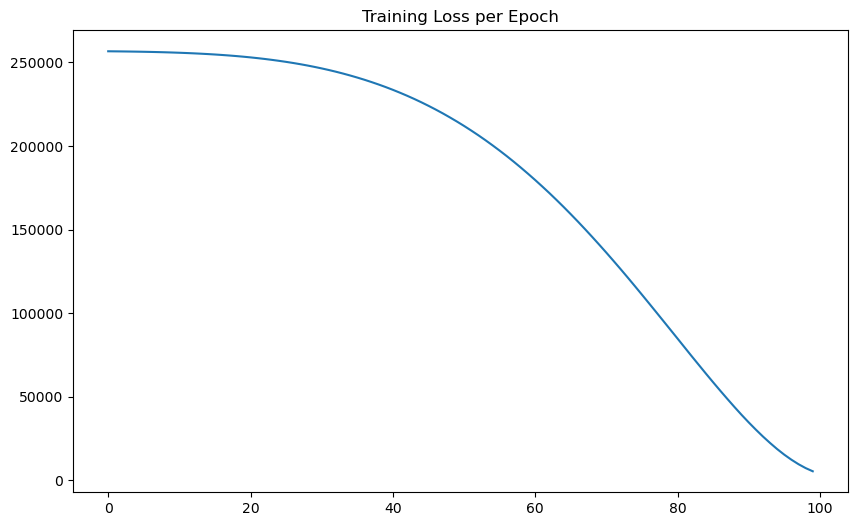

In [10]:
plt.figure(figsize=(10,6))
sns.lineplot(x=range(0,100),y=loss[:100])
plt.title("Training Loss per Epoch")

### Compare final evaluation (MSE) on training set and test set.

These should hopefully be fairly close to each other.

In [11]:
model.metrics_names

['loss']

In [12]:
training_score = model.evaluate(X_train,y_train,verbose=0)
test_score = model.evaluate(X_test,y_test,verbose=0)

In [13]:
training_score

24.00292205810547

In [14]:
test_score

25.00310707092285

### Further Evaluations

In [15]:
test_predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


In [16]:
test_predictions

array([[405.36618],
       [623.1782 ],
       [591.77905],
       [572.09204],
       [367.00833],
       [578.94244],
       [515.14   ],
       [458.98297],
       [549.1529 ],
       [447.39954],
       [611.44226],
       [548.49866],
       [419.16678],
       [408.9947 ],
       [650.5775 ],
       [437.24478],
       [508.1253 ],
       [659.70056],
       [662.2312 ],
       [565.19806],
       [334.56885],
       [444.8459 ],
       [382.7387 ],
       [378.8742 ],
       [566.365  ],
       [610.3816 ],
       [532.2478 ],
       [427.86923],
       [655.1599 ],
       [414.04742],
       [442.54648],
       [485.0436 ],
       [438.40686],
       [681.47815],
       [424.64038],
       [417.83853],
       [501.55646],
       [550.2414 ],
       [509.78394],
       [395.67957],
       [618.188  ],
       [416.61307],
       [604.08325],
       [445.78696],
       [501.87643],
       [581.1803 ],
       [668.35815],
       [490.21643],
       [318.7219 ],
       [485.36603],


In [17]:
pred_df = pd.DataFrame(y_test,columns=['Test Y'])

In [18]:
pred_df

,Test Y
0,402.296319
1,624.156198
2,582.455066
3,578.588606
4,371.224104
...,...
295,525.704657
296,502.909473
297,612.727910
298,417.569725


In [19]:
test_predictions = pd.Series(test_predictions.reshape(300,))

In [20]:
test_predictions

0      405.366180
1      623.178223
2      591.779053
3      572.092041
4      367.008331
          ...    
295    528.979248
296    515.514465
297    609.291260
298    416.896362
299    411.032104
Length: 300, dtype: float32

In [21]:
pred_df = pd.concat([pred_df,test_predictions],axis=1)

In [22]:
pred_df.columns = ['Test Y','Model Predictions']

In [23]:
pred_df

,Test Y,Model Predictions
0,402.296319,405.366180
1,624.156198,623.178223
2,582.455066,591.779053
3,578.588606,572.092041
4,371.224104,367.008331
...,...,...
295,525.704657,528.979248
296,502.909473,515.514465
297,612.727910,609.291260
298,417.569725,416.896362


<Axes: xlabel='Model Predictions', ylabel='Test Y'>

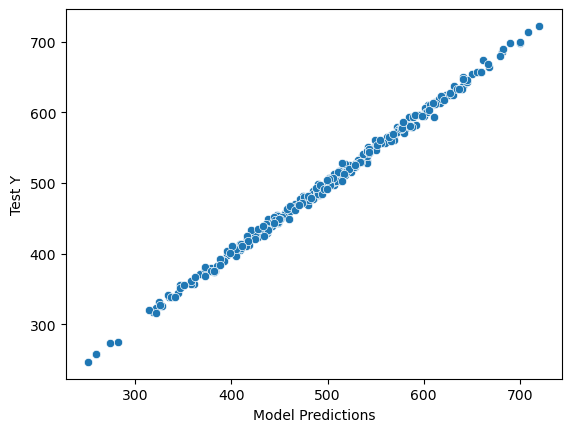

In [24]:
sns.scatterplot(x='Model Predictions',y='Test Y',data=pred_df)

<Axes: xlabel='Error', ylabel='Count'>

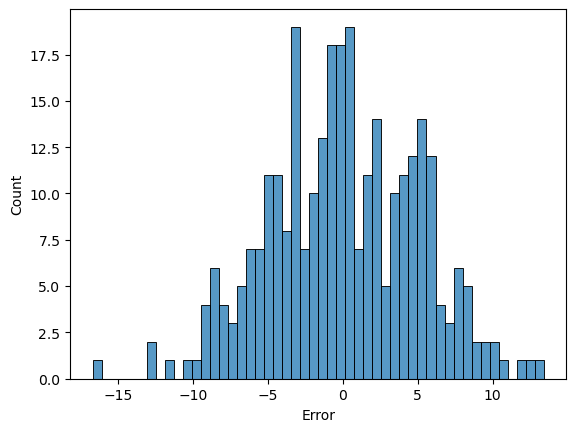

In [25]:
pred_df['Error'] = pred_df['Test Y'] - pred_df['Model Predictions']
sns.histplot(pred_df['Error'],bins=50)

In [26]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

mean_absolute_error(pred_df['Test Y'],pred_df['Model Predictions'])

4.013510302735408

In [27]:
mean_squared_error(pred_df['Test Y'],pred_df['Model Predictions'])

25.003110334297446

In [28]:
#RMSE
test_score**0.5

5.000310697438995

In [29]:
# [[Feature1, Feature2]]
new_gem = [[998,1000]]

In [30]:
scaler.transform(new_gem)

array([[0.14117652, 0.53968792]])

In [31]:
new_gem = scaler.transform(new_gem)

In [32]:
model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[419.95514]], dtype=float32)

## Saving and Loading a Model

In [33]:
from tensorflow.keras.models import load_model

model.save('my_model.keras')

In [34]:
later_model = load_model('my_model.keras')
later_model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


array([[419.95514]], dtype=float32)

<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2006/Session%2006%20-%20Matplotlib%20Concepts_1.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>